In [1]:
from transformers import AutoModelForCausalLM, AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2-0.5B")
model = AutoModelForCausalLM.from_pretrained("Qwen/Qwen2-0.5B")

In [2]:
tokenizer.encode(" positive"), tokenizer.encode(" negative"), tokenizer.encode("positive"), tokenizer.encode("negative")

([6785], [8225], [30487], [42224])

In [3]:
def score(sample, prompt_template):
    """
    Predict whether a review is positive or negative using a generative model with a custom prompt.

    Parameters:
    -----------
    sample : dict
        A dictionary containing at least the key 'text' with the review text.
    prompt_template : str
        A template string for the prompt, where the review text will be inserted.
        Example: "Question: Is the following review positive or negative about the movie?\nReview: {review} Answer:"

    Returns:
    --------
    dict
        The input sample dictionary updated with a new key 'pred':
        - 1 if predicted positive
        - 0 if predicted negative
    """
    # Fill in the prompt template with the review text
    prompt = prompt_template.format(review=sample['text'])

    # Tokenize the prompt
    input_ids = tokenizer(prompt, truncation=True, return_tensors="pt").input_ids

    # Get logits from the model
    final_logits = model(input_ids).logits[0, -1]

    # Assign prediction based on token logits
    sample["pred"] = 1 if final_logits[6785] > final_logits[8225] else 0

    return sample

In [4]:
sample_review = {"text": "This movie was terrible!"}
prompt_template = "Question: Is the following review positive or negative about the movie?\nReview: {review} Answer:"

score(sample_review, prompt_template)

{'text': 'This movie was terrible!', 'pred': 0}

In [5]:
from datasets import load_dataset

dataset = load_dataset("imdb")["train"]

In [6]:
shuffled_dataset = dataset.shuffle(seed=42)
small_dataset = shuffled_dataset.select(range(100))
small_dataset

Dataset({
    features: ['text', 'label'],
    num_rows: 100
})

In [7]:
prompt_template = "Question: Is the following review positive or negative about the movie?\nReview: {review} Answer:"

updated_dataset = small_dataset.map(score,fn_kwargs={"prompt_template": prompt_template})
updated_dataset

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

Dataset({
    features: ['text', 'label', 'pred'],
    num_rows: 100
})

In [8]:
import evaluate

confusion_matrix = evaluate.load("confusion_matrix")
cm = confusion_matrix.compute(
    references=updated_dataset["label"],
    predictions=updated_dataset["pred"],
)
cm

{'confusion_matrix': array([[53,  0],
        [18, 29]], dtype=int64)}

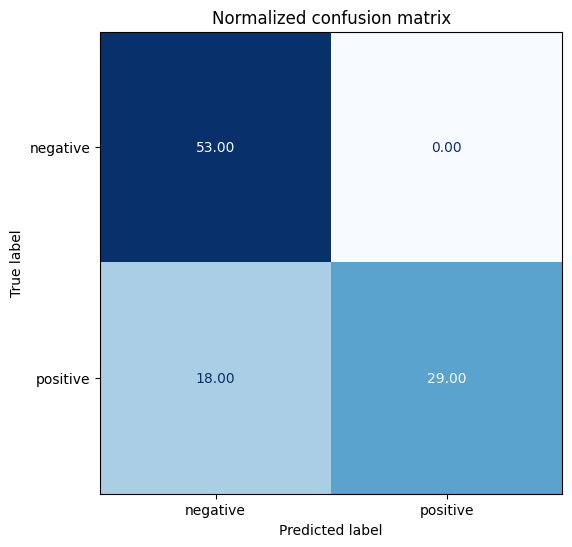

In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm["confusion_matrix"],
    display_labels=["negative", "positive"],
)
disp.plot(cmap="Blues", values_format=".2f", ax=ax, colorbar=False)

plt.title("Normalized confusion matrix")
plt.show()

In [10]:
df = updated_dataset.to_pandas()
df.head()

,text,label,pred
0,There is no relation at all between Fortier an...,1,0
1,This movie is a great. The plot is very true t...,1,1
2,"George P. Cosmatos' ""Rambo: First Blood Part I...",0,0
3,In the process of trying to establish the audi...,1,0
4,"Yeh, I know -- you're quivering with excitemen...",0,0
